In [1]:
# Core libraries
import os
import random
import matplotlib.pyplot as plt
from PIL import Image

# PyTorch
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

# Torchvision
from torchvision import transforms, models

# Metrics
from sklearn.metrics import accuracy_score, classification_report

# Progress bar
from tqdm import tqdm

In [2]:
# Dataset root path
DATASET_PATH = "/kaggle/input/datasets/wish096/realvsfake-81k-by-wish/RealVsFake/RealVsFake"

# Real and Fake folders
real_dir = os.path.join(DATASET_PATH, "Real")
fake_dir = os.path.join(DATASET_PATH, "Fake")

In [3]:
# Function to load all image paths from a folder
def load_images(folder):
    return [os.path.join(folder, f) for f in os.listdir(folder)]

# Load datasets
real_images = load_images(real_dir)
fake_images = load_images(fake_dir)

print("Real images:", len(real_images))
print("Fake images:", len(fake_images))

Real images: 81000
Fake images: 80972


In [4]:
# Total subset size
TOTAL_SIZE = 120000

# Half real, half fake
half_size = TOTAL_SIZE // 2

# Shuffle first
random.seed(42)
random.shuffle(real_images)
random.shuffle(fake_images)

# Take subset
real_subset = real_images[:half_size]
fake_subset = fake_images[:half_size]

print("Real subset:", len(real_subset))
print("Fake subset:", len(fake_subset))

Real subset: 60000
Fake subset: 60000


In [5]:
def split_data(data):
    n = len(data)
    train_end = int(n * 0.7)
    val_end   = int(n * 0.85)

    train = data[:train_end]
    val   = data[train_end:val_end]
    test  = data[val_end:]

    return train, val, test

# Split
real_train, real_val, real_test = split_data(real_subset)
fake_train, fake_val, fake_test = split_data(fake_subset)

In [6]:
# Labels: 0 = Real, 1 = Fake

train_data = [(img, 0) for img in real_train] + [(img, 1) for img in fake_train]
val_data   = [(img, 0) for img in real_val]   + [(img, 1) for img in fake_val]
test_data  = [(img, 0) for img in real_test]  + [(img, 1) for img in fake_test]

# Shuffle
random.shuffle(train_data)
random.shuffle(val_data)
random.shuffle(test_data)

# Check sizes
print("Train:", len(train_data))
print("Val:", len(val_data))
print("Test:", len(test_data))

Train: 84000
Val: 18000
Test: 18000


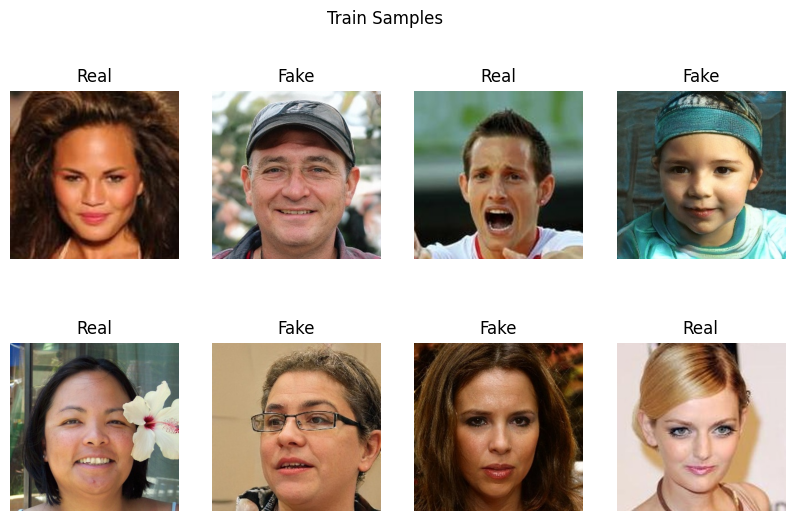

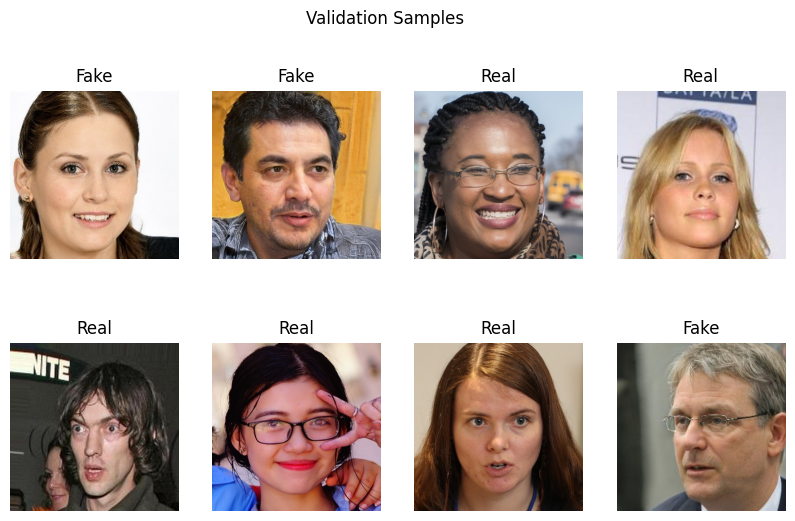

In [7]:
# Function to display sample images
def show_samples(data, title):
    plt.figure(figsize=(10,6))
    for i in range(8):
        img_path, label = data[i]
        img = Image.open(img_path)

        plt.subplot(2,4,i+1)
        plt.imshow(img)
        plt.title("Real" if label == 0 else "Fake")
        plt.axis("off")

    plt.suptitle(title)
    plt.show()

# Show samples before training
show_samples(train_data, "Train Samples")
show_samples(val_data, "Validation Samples")

In [8]:
train_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

val_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

In [9]:
# Custom dataset class
class FaceDataset(Dataset):
    def __init__(self, data, transform=None):
        self.data = data
        self.transform = transform

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        img_path, label = self.data[idx]

        image = Image.open(img_path).convert("RGB")

        if self.transform:
            image = self.transform(image)

        return image, label

In [10]:
train_dataset = FaceDataset(train_data, train_transforms)
val_dataset   = FaceDataset(val_data, val_transforms)
test_dataset  = FaceDataset(test_data, val_transforms)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
val_loader   = DataLoader(val_dataset, batch_size=64, shuffle=False)
test_loader  = DataLoader(test_dataset, batch_size=64, shuffle=False)

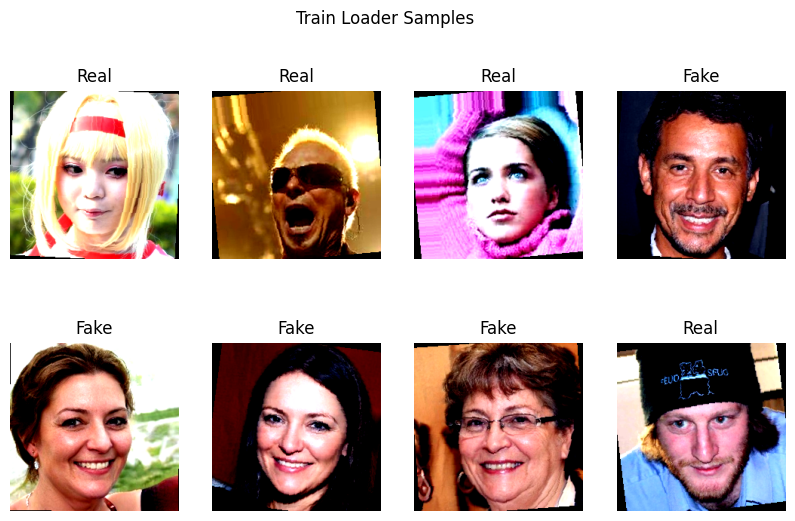

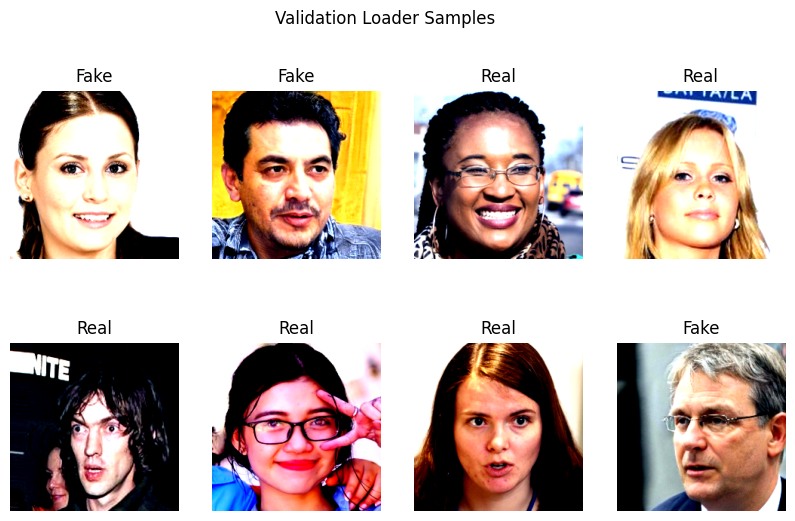

In [11]:
import matplotlib.pyplot as plt
import numpy as np

# Function to unnormalize image
def unnormalize(img):
    img = img.numpy().transpose((1, 2, 0))
    img = (img * 0.5) + 0.5  # reverse normalization [0.5, 0.5, 0.5]
    img = np.clip(img, 0, 1)
    return img

# Display batch from loader
def show_batch(loader, title="Batch Images"):
    images, labels = next(iter(loader))

    plt.figure(figsize=(10,6))

    for i in range(8):
        img = unnormalize(images[i])
        label = labels[i].item()

        plt.subplot(2,4,i+1)
        plt.imshow(img)
        plt.title("Real" if label == 0 else "Fake")
        plt.axis("off")

    plt.suptitle(title)
    plt.show()

# Show from loaders
show_batch(train_loader, "Train Loader Samples")
show_batch(val_loader, "Validation Loader Samples")

In [12]:
# Check overlap between splits
train_paths = set([x[0] for x in train_data])
val_paths = set([x[0] for x in val_data])
test_paths = set([x[0] for x in test_data])

print("Train ∩ Val:", len(train_paths & val_paths))
print("Train ∩ Test:", len(train_paths & test_paths))
print("Val ∩ Test:", len(val_paths & test_paths))

Train ∩ Val: 0
Train ∩ Test: 0
Val ∩ Test: 0


In [13]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


model = models.vgg16(weights=models.VGG16_Weights.DEFAULT)

for param in model.features.parameters():
    param.requires_grad = False

model.classifier = nn.Sequential(
    nn.Linear(25088, 128),
    nn.ReLU(),
    nn.Dropout(0.5),
    nn.Linear(128, 2)
)

model = model.to(device)

Downloading: "https://download.pytorch.org/models/vgg16-397923af.pth" to /root/.cache/torch/hub/checkpoints/vgg16-397923af.pth


100%|██████████| 528M/528M [00:02<00:00, 189MB/s]  


In [14]:
# Loss with label smoothing (prevents overconfidence)
criterion = nn.CrossEntropyLoss(label_smoothing=0.1)

# Optimizer
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

# Learning rate scheduler
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', patience=2, factor=0.3
)

In [15]:
def train_one_epoch(model, loader):
    model.train()
    total_loss, correct = 0, 0

    loop = tqdm(loader, desc="Training", leave=False)

    for images, labels in loop:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)

        loss = criterion(outputs, labels)
        loss.backward()

        # Prevent exploding gradients
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)

        optimizer.step()

        total_loss += loss.item()
        preds = outputs.argmax(dim=1)
        correct += (preds == labels).sum().item()

        acc = correct / ((loop.n + 1) * loader.batch_size)
        loop.set_postfix(loss=loss.item(), acc=acc)

    return total_loss / len(loader), correct / len(loader.dataset)

In [16]:
def evaluate(model, loader):
    model.eval()
    total_loss, correct = 0, 0

    loop = tqdm(loader, desc="Validation", leave=False)

    with torch.no_grad():
        for images, labels in loop:
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            total_loss += loss.item()
            preds = outputs.argmax(dim=1)
            correct += (preds == labels).sum().item()

            acc = correct / ((loop.n + 1) * loader.batch_size)
            loop.set_postfix(loss=loss.item(), acc=acc)

    return total_loss / len(loader), correct / len(loader.dataset)

In [17]:
# 📊 Store history
train_losses, val_losses = [], []
train_accs, val_accs = [], []

best_val_acc = 0
epochs = 10

for epoch in range(epochs):
    print(f"\nEpoch {epoch+1}/{epochs}")

    # ================= TRAIN =================
    model.train()
    total_loss, correct, total = 0, 0, 0

    train_loop = tqdm(train_loader, desc="Training", leave=False)

    for images, labels in train_loop:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)

        loss = criterion(outputs, labels)
        loss.backward()

        # Gradient clipping
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)

        optimizer.step()

        # Metrics
        total_loss += loss.item()
        preds = outputs.argmax(dim=1)

        correct += (preds == labels).sum().item()
        total += labels.size(0)

        # Live accuracy (FIXED)
        train_loop.set_postfix(
            loss=loss.item(),
            acc=correct / total
        )

    train_acc = correct / total
    train_loss = total_loss / len(train_loader)

    # ================= VALIDATION =================
    model.eval()
    total_loss, correct, total = 0, 0, 0

    val_loop = tqdm(val_loader, desc="Validation", leave=False)

    with torch.no_grad():
        for images, labels in val_loop:
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            total_loss += loss.item()
            preds = outputs.argmax(dim=1)

            correct += (preds == labels).sum().item()
            total += labels.size(0)

            val_loop.set_postfix(
                loss=loss.item(),
                acc=correct / total
            )

    val_acc = correct / total
    val_loss = total_loss / len(val_loader)

    # ================= SCHEDULER =================
    scheduler.step(val_loss)

    # ================= SAVE HISTORY =================
    train_losses.append(train_loss)
    val_losses.append(val_loss)

    train_accs.append(train_acc)
    val_accs.append(val_acc)

    # ================= LOG =================
    print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f}")
    print(f"Val Loss:   {val_loss:.4f} | Val Acc:   {val_acc:.4f}")

    # ================= SAVE BEST MODEL =================
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), "best_model.pth")
        print("✅ Best model saved!")


Epoch 1/10


Train Loss: 0.3916 | Train Acc: 0.8811
Val Loss:   0.3240 | Val Acc:   0.9274
✅ Best model saved!

Epoch 2/10


Train Loss: 0.3397 | Train Acc: 0.9213
Val Loss:   0.3115 | Val Acc:   0.9378
✅ Best model saved!

Epoch 3/10


Train Loss: 0.3228 | Train Acc: 0.9338
Val Loss:   0.2958 | Val Acc:   0.9489
✅ Best model saved!

Epoch 4/10


Train Loss: 0.3128 | Train Acc: 0.9415
Val Loss:   0.2897 | Val Acc:   0.9526
✅ Best model saved!

Epoch 5/10


...

Train Loss: 0.2999 | Train Acc: 0.9504
Val Loss:   0.2837 | Val Acc:   0.9578
✅ Best model saved!

Epoch 7/10


Train Loss: 0.2962 | Train Acc: 0.9537
Val Loss:   0.2817 | Val Acc:   0.9583
✅ Best model saved!

Epoch 8/10


Train Loss: 0.2938 | Train Acc: 0.9551
Val Loss:   0.2824 | Val Acc:   0.9589
✅ Best model saved!

Epoch 9/10


Train Loss: 0.2911 | Train Acc: 0.9563
Val Loss:   0.2784 | Val Acc:   0.9617
✅ Best model saved!

Epoch 10/10


Train Loss: 0.2890 | Train Acc: 0.9584
Val Loss:   0.2763 | Val Acc:   0.9625
✅ Best model saved!


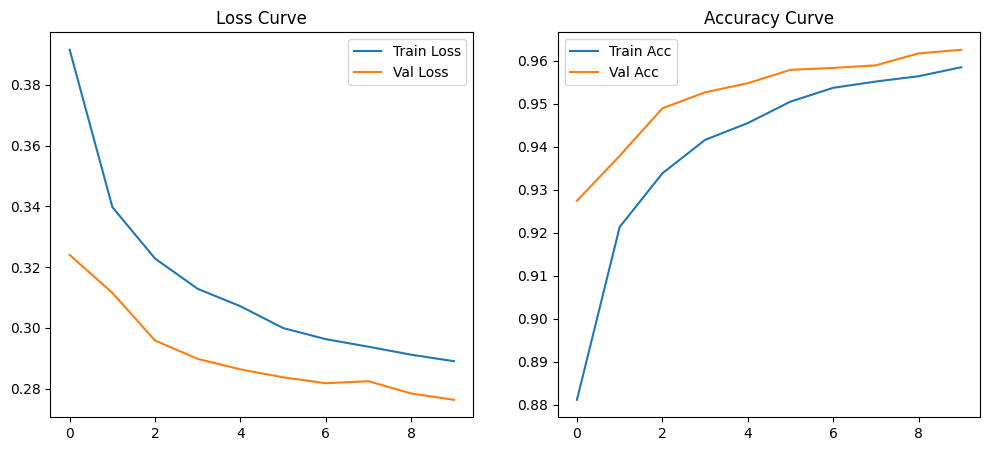

In [18]:
plt.figure(figsize=(12,5))

# Loss curve
plt.subplot(1,2,1)
plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Val Loss")
plt.title("Loss Curve")
plt.legend()

# Accuracy curve
plt.subplot(1,2,2)
plt.plot(train_accs, label="Train Acc")
plt.plot(val_accs, label="Val Acc")
plt.title("Accuracy Curve")
plt.legend()

plt.show()

In [19]:
model.load_state_dict(torch.load("best_model.pth"))
model.eval()

y_true, y_pred = [], []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)

        outputs = model(images)
        preds = outputs.argmax(dim=1).cpu().numpy()

        y_pred.extend(preds)
        y_true.extend(labels.numpy())

print("Test Accuracy:", accuracy_score(y_true, y_pred))
print(classification_report(y_true, y_pred))

Test Accuracy: 0.9626666666666667
              precision    recall  f1-score   support

           0       0.97      0.96      0.96      9000
           1       0.96      0.97      0.96      9000

    accuracy                           0.96     18000
   macro avg       0.96      0.96      0.96     18000
weighted avg       0.96      0.96      0.96     18000



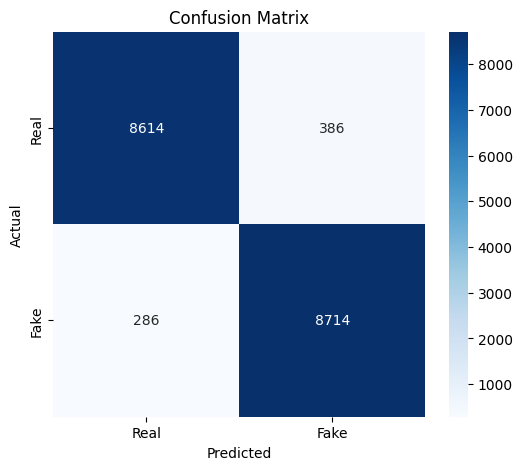


Classification Report:
              precision    recall  f1-score   support

        Real       0.97      0.96      0.96      9000
        Fake       0.96      0.97      0.96      9000

    accuracy                           0.96     18000
   macro avg       0.96      0.96      0.96     18000
weighted avg       0.96      0.96      0.96     18000



In [20]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report

model.eval()

y_true = []
y_pred = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)

        outputs = model(images)
        preds = outputs.argmax(dim=1).cpu().numpy()

        y_pred.extend(preds)
        y_true.extend(labels.numpy())

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=["Real", "Fake"],
            yticklabels=["Real", "Fake"])

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

# Classification Report
print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=["Real", "Fake"]))

In [21]:
torch.save(model.state_dict(), "final_model.pth")
print("✅ Model saved as final_model.pth")

✅ Model saved as final_model.pth


In [22]:
import random
class_names=[ 'Real', 'Fake']

def show_predictions(model, dataset, num_images=6):
    model.eval()
    
    indices = random.sample(range(len(dataset)), num_images)
    
    plt.figure(figsize=(12, 8))
    
    for i, idx in enumerate(indices):
        img, label = dataset[idx]
        img_input = img.unsqueeze(0).to(device)
        
        with torch.no_grad():
            output = model(img_input)
            _, pred = torch.max(output, 1)
        
        img_np = img.permute(1, 2, 0).numpy()
        img_np = (img_np * [0.229,0.224,0.225] + [0.485,0.456,0.406])
        img_np = np.clip(img_np, 0, 1)
        
        plt.subplot(2, 3, i+1)
        plt.imshow(img_np)
        plt.title(f"True: {class_names[label]} | Pred: {class_names[pred.item()]}")
        plt.axis('off')
    
    plt.show()

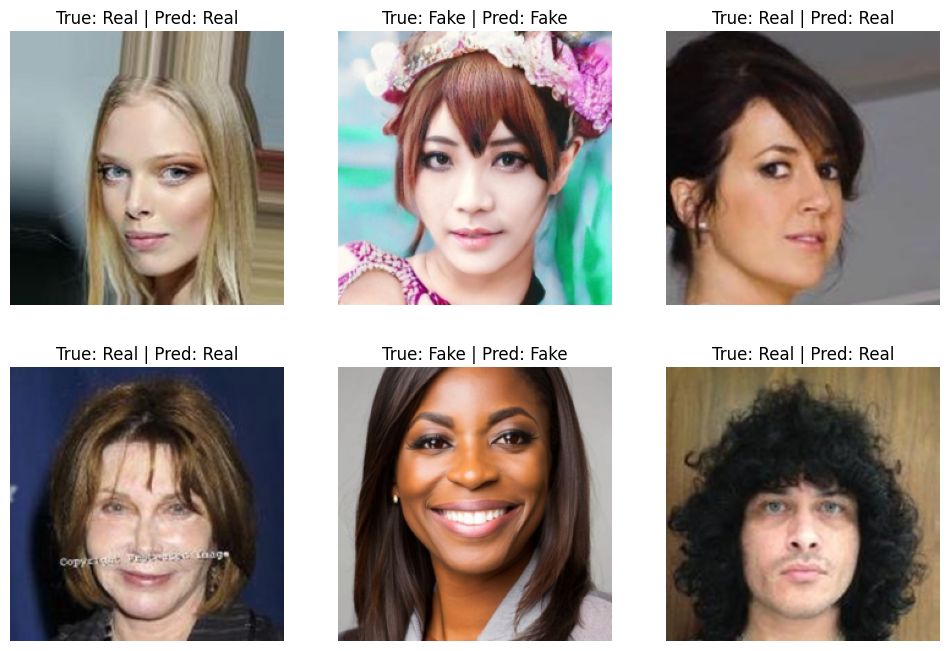

In [27]:
show_predictions(model, val_dataset, num_images=6)

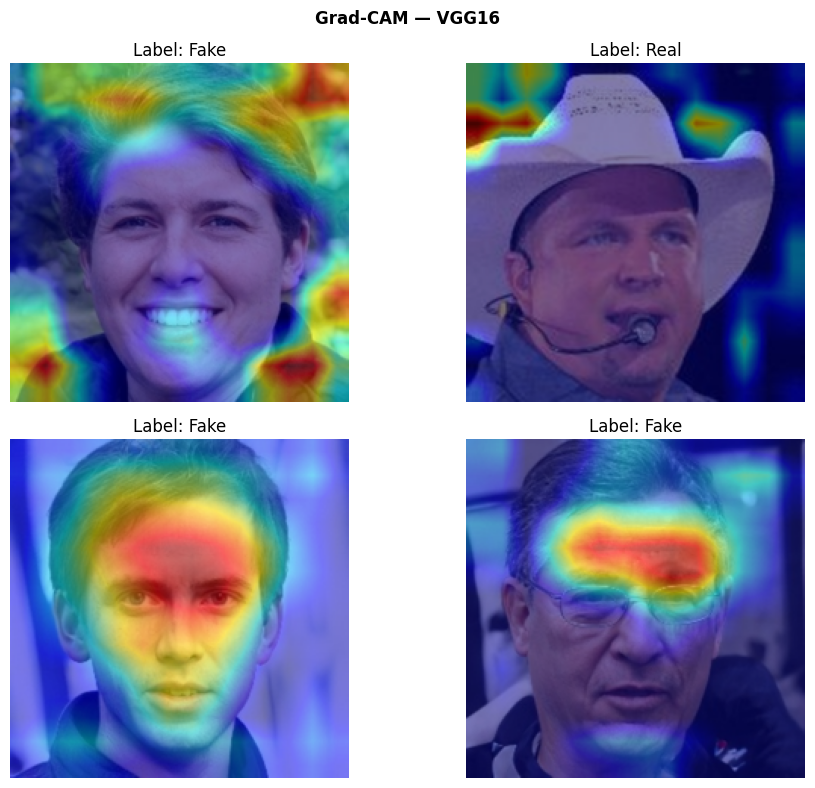

In [38]:
!pip install grad-cam
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image
for param in model.features[24:].parameters():
    param.requires_grad = True

target_layer = model.features[28]  # last conv layer in VGG16

cam = GradCAM(model=model, target_layers=[target_layer])

def show_gradcam_vgg16(model, dataset, num_images=4):
    model.train()

    indices = random.sample(range(len(dataset)), num_images)

    plt.figure(figsize=(10, 8))

    for i, idx in enumerate(indices):
        img, label = dataset[idx]

        input_tensor = img.unsqueeze(0).to(device)

        grayscale_cam = cam(input_tensor=input_tensor)[0]

        img_np = img.permute(1, 2, 0).numpy()
        img_np = (img_np * [0.229, 0.224, 0.225] + [0.485, 0.456, 0.406])
        img_np = np.clip(img_np, 0, 1)

        visualization = show_cam_on_image(img_np, grayscale_cam, use_rgb=True)

        plt.subplot(2, 2, i + 1)
        plt.imshow(visualization)
        plt.title(f"Label: {class_names[label]}")
        plt.axis('off')

    plt.suptitle("Grad-CAM — VGG16", fontweight="bold")
    plt.tight_layout()
    plt.show()

show_gradcam_vgg16(model, val_dataset, num_images=4)